In [1]:
import os
import gc
import json
import tensorflow as tf
import matplotlib.pyplot as plt


tf.config.threading.set_inter_op_parallelism_threads(4)
tf.config.threading.set_intra_op_parallelism_threads(4)

gc.collect()
tf.keras.backend.clear_session()

print("TensorFlow Version:", tf.__version__)
tf.keras.utils.set_random_seed(42)


TensorFlow Version: 2.21.0


In [2]:
TRAIN_DIR = "../dataset/train"
VALID_DIR = "../dataset/valid"

MODEL_PATH = "../models/trained_plant_disease_model.keras"
HISTORY_PATH = "../models/training_history.json"

IMG_SIZE = (128,128)
BATCH_SIZE = 16
EPOCHS = 20

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

Found 70295 files belonging to 38 classes.


In [4]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 17572 files belonging to 38 classes.


In [5]:
class_names = train_ds.class_names

# Save class names for prediction
with open("../models/class_names.json", "w") as f:
    json.dump(class_names, f, indent=4)

print("Total Classes:", len(class_names))
print(class_names[:5])

Total Classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(
    buffer_size=AUTOTUNE
)

val_ds = val_ds.prefetch(
    buffer_size=AUTOTUNE
)

In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [8]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

In [9]:
inputs = tf.keras.Input(
    shape=(128,128,3)
)

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dense(
    512,
    activation="relu"
)(x)

x = tf.keras.layers.Dropout(0.5)(x)

outputs = tf.keras.layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = tf.keras.Model(
    inputs,
    outputs
)

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [11]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        19,494 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,933,350 (11.19 MB)

 Trainable params: 675,366 (2.58 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    MODEL_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

In [15]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/20
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.6008 - loss: 1.4722
Epoch 1: val_accuracy improved from None to 0.89557, saving model to ../models/trained_plant_disease_model.keras

Epoch 1: finished saving model to ../models/trained_plant_disease_model.keras
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 377s 85ms/step - accuracy: 0.7514 - loss: 0.8634 - val_accuracy: 0.8956 - val_loss: 0.3442 - learning_rate: 1.0000e-04
Epoch 2/20
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8755 - loss: 0.3986
Epoch 2: val_accuracy improved from 0.89557 to 0.91504, saving model to ../models/trained_plant_disease_model.keras

Epoch 2: finished saving model to ../models/trained_plant_disease_model.keras
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 366s 83ms/step - accuracy: 0.8826 - loss: 0.3737 - val_accuracy: 0.9150 - val_loss: 0.2656 - learning_rate: 1.0000e-04
Epoch 3/20
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9037 - loss: 0.2995
Epoch 3: val_accuracy improved from 0.91504 to

In [16]:
train_loss, train_acc = model.evaluate(train_ds)

val_loss, val_acc = model.evaluate(val_ds)

print(f"Training Accuracy: {train_acc:.4f}")

print(f"Validation Accuracy: {val_acc:.4f}")

4394/4394 ━━━━━━━━━━━━━━━━━━━━ 261s 59ms/step - accuracy: 0.9648 - loss: 0.1010
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 66s 60ms/step - accuracy: 0.9547 - loss: 0.1295
Training Accuracy: 0.9648
Validation Accuracy: 0.9547


In [17]:
metrics = {
    "train_accuracy": float(train_acc),
    "validation_accuracy": float(val_acc),
    "train_loss": float(train_loss),
    "validation_loss": float(val_loss)
}

with open("../models/evaluation.json", "w") as f:
    json.dump(metrics, f, indent=4)

In [18]:
with open(
    HISTORY_PATH,
    "w"
) as f:

    json.dump(
        history.history,
        f
    )

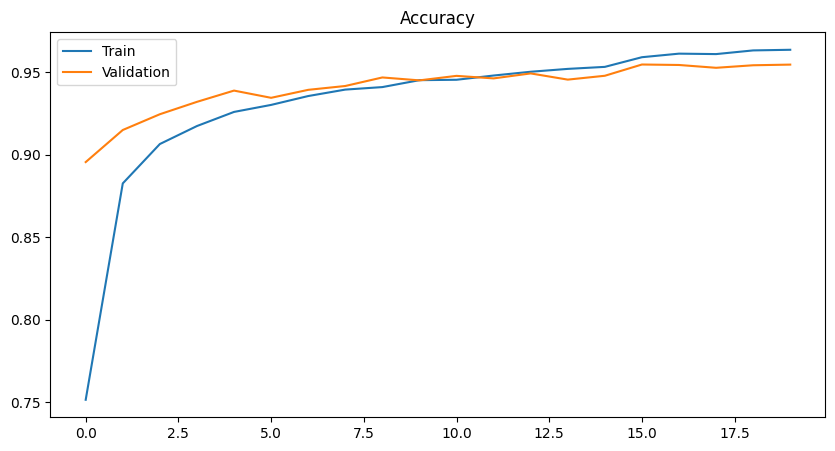

In [19]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Train'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation'
)

plt.title("Accuracy")

plt.legend()

plt.show()

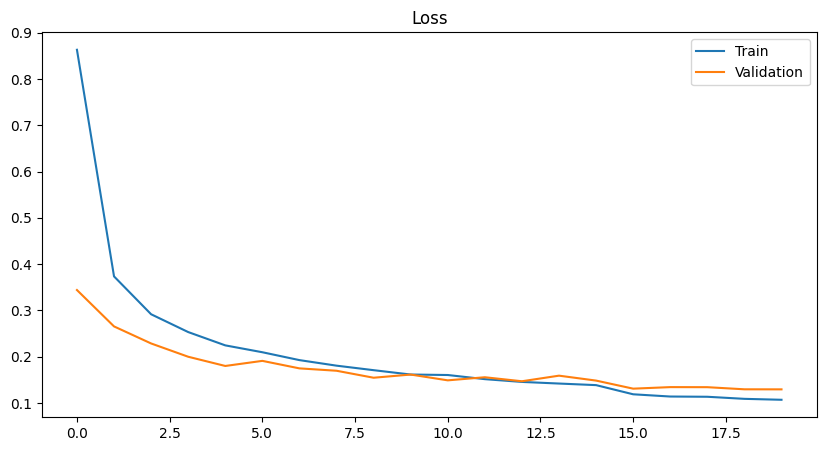

In [20]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Train'
)

plt.plot(
    history.history['val_loss'],
    label='Validation'
)

plt.title("Loss")

plt.legend()

plt.show()